# 01 — NHANES Data Preparation Pipeline
### Two-Stage Non-Laboratory Screening for Unrecognized HbA1c-Defined Dysglycemia
**Author:** Felix (Thesis Research)  
**Data Cycle:** CDC / NCHS NHANES August 2021 – August 2023  
**Pipeline Phase:** Phase 3 Canonical Dataset Construction & Replication  

---

## 1. Research Data Source & Background

### 1.1 Study Context & Dataset Transition
This research investigates a **two-stage non-laboratory screening strategy** to detect unrecognized dysglycemia in community adults. 
* **Data Source:** Official public microdata from the **National Health and Nutrition Examination Survey (NHANES) August 2021–August 2023** cycle, administered by the National Center for Health Statistics (NCHS) of the U.S. Centers for Disease Control and Prevention (CDC).
* **Methodological Origin:** Public NHANES data serves as the research benchmark for this thesis following the administrative inaccessibility of the originally intended Indonesian national health survey microdata (Survei Kesehatan Indonesia / SKI 2023).
* **External Validity Scope:** The predictive models developed in this study evaluate algorithmic screening mechanics and non-linear risk associations on standardized epidemiological examination data. **This thesis does not claim external validity to the Indonesian general population.**
* **Survey Weighting Scope:** Primary machine learning evaluations in this study are unweighted participant-level predictive models. Consequently, predictive accuracy metrics are **not claimed as nationally representative U.S. prevalence estimates**. Survey design variables (`WTPH2YR`, `SDMVSTRA`, `SDMVPSU`) are strictly preserved as descriptive metadata.

### 1.2 Screening Paradigm: Unrecognized Dysglycemia vs. Future Incidence
This study models **cross-sectional screening for currently present, unrecognized dysglycemia**. It is:
1. **NOT longitudinal prediction:** We are not predicting future 5-year or 10-year diabetes incidence.
2. **NOT clinical diagnosis:** The non-laboratory Stage-1 instrument stratifies individuals who warrant confirmatory laboratory testing (Stage 2 HbA1c).


## 2. NHANES Components Used

Eight official CDC/NCHS files from the August 2021–August 2023 release are utilized:

| File Name | Component Category | Module Title | Purpose in Research | Key Target Variables |
|:---|:---|:---|:---|:---|
| **`DEMO_L.xpt`** | Demographics | Demographic Variables | Base cohort, age, biological sex, interview weights | `SEQN`, `RIDAGEYR`, `RIAGENDR`, `WTINT2YR` |
| **`BMX_L.xpt`** | Examination | Body Measures | Physical examination anthropometrics | `BMXBMI` (BMI), `BMXWAIST` (Waist circumference) |
| **`BPQ_L.xpt`** | Questionnaire | Blood Pressure & Cholesterol | Self-reported hypertension history | `BPQ020` (Ever told high blood pressure) |
| **`SMQ_L.xpt`** | Questionnaire | Smoking - Cigarette Use | Lifetime smoking history | `SMQ020` (Smoked $\ge 100$ cigarettes lifetime) |
| **`PAQ_L.xpt`** | Questionnaire | Physical Activity | Self-reported daily sedentary minutes | `PAD680` (Minutes of sitting per day) |
| **`DIQ_L.xpt`** | Questionnaire | Diabetes | Prior diagnosis exclusion (Cohort E definition) | `DIQ010` (Known diabetes), `DIQ160` (Known prediabetes) |
| **`GHB_L.xpt`** | Laboratory | Glycohemoglobin | Primary reference standard (HbA1c) | `LBXGH` (HbA1c, %), `WTPH2YR` (Phlebotomy weight) |
| **`GLU_L.xpt`** | Laboratory | Fasting Glucose | Secondary reference (FPG subsample) | `LBXGLU` (Fasting glucose, mg/dL), `WTSAF2YR` |


In [1]:
import sys, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Configure clean aesthetic plotting
plt.rcParams.update({
    'font.sans-serif': 'DejaVu Sans',
    'figure.autolayout': True,
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8
})

# Robust path resolution independent of working directory
current = Path.cwd().resolve()
candidates = [current, current.parent, current.parent.parent]
PROJECT_ROOT = None
for c in candidates:
    if (c / "nhanes_feasibility_2021_2023").exists():
        PROJECT_ROOT = c
        break
if PROJECT_ROOT is None:
    PROJECT_ROOT = current

NHANES_DIR = PROJECT_ROOT / "nhanes_feasibility_2021_2023"
RAW_DIR = NHANES_DIR / "raw"
PROCESSED_DIR = NHANES_DIR / "processed_phase3"

print(f"Project Root: {PROJECT_ROOT}")
print(f"Raw XPT Path: {RAW_DIR}")
print(f"Processed Phase 3 Path: {PROCESSED_DIR}")
assert RAW_DIR.exists(), f"Raw directory missing: {RAW_DIR}"


Project Root: C:\Users\Felix\Documents\Skripsi
Raw XPT Path: C:\Users\Felix\Documents\Skripsi\nhanes_feasibility_2021_2023\raw
Processed Phase 3 Path: C:\Users\Felix\Documents\Skripsi\nhanes_feasibility_2021_2023\processed_phase3


## 3. Loading Raw XPT Files & SAS Floating-Point Underflow Normalization

### Critical Methodological Rule: SAS Zero Handling
When SAS Transport files (`.xpt`) are read into pandas via `read_sas`, exact numeric zeros are occasionally decoded as floating-point underflow values (e.g., $5.3976 	imes 10^{-79}$).
* Without normalization, logical checks such as `WTSAF2YR > 0` or `WTPH2YR > 0` will evaluate to `True` for zero-weighted participants, leading to invalid analytic sample counts.
* The helper function `normalize_sas_zeros` replaces any numeric value with absolute value $< 10^{-10}$ with `0.0`.


In [2]:
def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

def normalize_sas_zeros(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize SAS floating-point underflow zeros (< 1e-10) to exact 0.0."""
    for col in df.select_dtypes(include=[np.number]).columns:
        df[col] = np.where((df[col].notna()) & (df[col].abs() < 1e-10), 0.0, df[col])
    return df

raw_files = [
    "DEMO_L.xpt", "BMX_L.xpt", "BPQ_L.xpt", "SMQ_L.xpt",
    "PAQ_L.xpt", "DIQ_L.xpt", "GHB_L.xpt", "GLU_L.xpt"
]

raw_manifest = []
dfs = {}

for fname in raw_files:
    fpath = RAW_DIR / fname
    assert fpath.exists(), f"Missing raw file: {fpath}"
    sha = sha256_file(fpath)
    df_raw = normalize_sas_zeros(pd.read_sas(str(fpath), format="xport"))
    dfs[fname.split(".")[0]] = df_raw
    raw_manifest.append({
        "file": fname,
        "rows": len(df_raw),
        "columns": df_raw.shape[1],
        "size_kb": round(fpath.stat().st_size / 1024, 1),
        "sha256": sha[:16] + "..."
    })

pd.DataFrame(raw_manifest)


,file,rows,columns,size_kb,sha256
0,DEMO_L.xpt,11933,27,2521.6,ca4374a158b493b8...
1,BMX_L.xpt,8860,22,1526.6,44440c416d9ad709...
2,BPQ_L.xpt,8501,6,400.1,0acde3af0526c375...
3,SMQ_L.xpt,9015,9,635.9,abbefebfa5585b1e...
4,PAQ_L.xpt,8153,8,399.9,de34acfed4523f10...
5,DIQ_L.xpt,11744,9,827.7,9535a023673ae869...
6,GHB_L.xpt,7199,3,169.9,67aee0353160e239...
7,GLU_L.xpt,3996,4,126.2,70f773ab37e3d848...


## 4. Participant-Level Merge Using SEQN

In NHANES, `SEQN` (Respondent Sequence Number) is the unique respondent identifier linking demographic, physical examination, laboratory, and questionnaire datasets.
* **Master Base:** All participant records are left-joined onto `DEMO_L` ($N = 11,933$).
* **Collision Guard:** Any non-`SEQN` column overlapping across components is dropped prior to merging to prevent silent column renaming (e.g. `_x`, `_y`).


In [3]:
demo = dfs["DEMO_L"].copy()
merged = demo.copy()

merge_order = ["BMX_L", "BPQ_L", "SMQ_L", "PAQ_L", "DIQ_L", "GHB_L", "GLU_L"]
for key in merge_order:
    comp = dfs[key].copy()
    overlap = (set(merged.columns) & set(comp.columns)) - {"SEQN"}
    if overlap:
        comp = comp.drop(columns=list(overlap))
    merged = merged.merge(comp, on="SEQN", how="left")

merged = normalize_sas_zeros(merged)
print(f"Successfully Merged Base: {merged.shape[0]:,} participants × {merged.shape[1]} raw variables")
assert len(merged) == 11933, f"Expected 11,933 rows, got {len(merged)}"
assert merged["SEQN"].is_unique, "Fatal: Duplicate SEQN detected in merged dataset!"


Successfully Merged Base: 11,933 participants × 81 raw variables


## 5. Study Population: Cohort E (Unrecognized Dysglycemia Screening)

### 5.1 Rationale for Excluding Known Diabetes and Prediabetes
The purpose of community screening is to **identify unrecognized disease** among individuals who currently believe they are healthy.
* Individuals with prior diagnosis (`DIQ010 == 1` for diabetes or `DIQ160 == 1` for prediabetes) already receive medical supervision and glycemic surveillance. Including them would artificially inflate screening model accuracy via circular self-selection.
* **Strict Exclusions:**
  * Age $< 18$ years (Pediatric participants excluded; non-laboratory screening guidelines apply to adults).
  * `DIQ010 != 2` (Self-reported diabetes: Yes=1, Borderline=3, Refused=7, Don't Know=9, Missing).
  * `DIQ160 != 2` (Self-reported prediabetes: Yes=1, Refused=7, Don't Know=9, Missing).
* **Strict Non-Response Handling:** Responses of Refused (7) or Don't Know (9) are **NOT** assumed to be "No". Inclusion strictly requires explicit negative response (`2 = No`).


In [4]:
# Base population counts
n_total = len(merged)
n_adults = int((merged["RIDAGEYR"] >= 18).sum())

# Cohort E Definition: Adult + DIQ010 == 2 + DIQ160 == 2
cohort_e_mask = (merged["RIDAGEYR"] >= 18) & (merged["DIQ010"] == 2) & (merged["DIQ160"] == 2)
n_cohort_e = int(cohort_e_mask.sum())

print(f"1. Total NHANES Survey Cohort:      N = {n_total:,}")
print(f"2. Adults (Age >= 18):              N = {n_adults:,} ({n_adults/n_total*100:.1f}%)")
print(f"3. Cohort E (No Prior Diagnosis):   N = {n_cohort_e:,} ({n_cohort_e/n_adults*100:.1f}% of adults)")

assert n_total == 11933, f"Expected 11,933 total, got {n_total}"
assert n_adults == 8153, f"Expected 8,153 adults, got {n_adults}"
assert n_cohort_e == 5907, f"Expected 5,907 Cohort E, got {n_cohort_e}"


1. Total NHANES Survey Cohort:      N = 11,933
2. Adults (Age >= 18):              N = 8,153 (68.3%)
3. Cohort E (No Prior Diagnosis):   N = 5,907 (72.5% of adults)


## 6. Primary Outcome: HbA1c-Defined Dysglycemia

### 6.1 Reference Standard: Glycohemoglobin (HbA1c)
* **Analyte:** `LBXGH` measured in the mobile examination center (MEC) via high-performance liquid chromatography (HPLC).
* **Analytical Validity:** In accordance with official CDC guidance, an analytically valid HbA1c observation requires non-missing `LBXGH` **and** positive 2-year phlebotomy examination weight (`WTPH2YR > 0`).
* **Binary Screening Target (`hba1c_dysglycemia`):**
  * `0 = Normal Glycemia`: $	ext{HbA1c} < 5.7\%$
  * `1 = Dysglycemia Range`: $	ext{HbA1c} \ge 5.7\%$ (incorporates both laboratory-defined prediabetes $[5.7\%-6.4\%]$ and undiagnosed diabetes $[\ge 6.5\%]$)
* **Descriptive Three-Class Variable (`hba1c_category`):**
  * `0`: $	ext{HbA1c} < 5.7\%$ (Normal laboratory range)
  * `1`: $5.7\% \le 	ext{HbA1c} < 6.5\%$ (Prediabetes laboratory range)
  * `2`: $	ext{HbA1c} \ge 6.5\%$ (Diabetes laboratory range)

*Note: This endpoint reflects laboratory-defined dysglycemia for screening stratification; it does not constitute clinical diagnosis.*


In [5]:
df_canonical = pd.DataFrame()
df_canonical["SEQN"] = merged["SEQN"].astype(int)

# Demographics & Cohort flags
df_canonical["age"] = merged["RIDAGEYR"]
df_canonical["DIQ010"] = merged["DIQ010"]
df_canonical["DIQ160"] = merged["DIQ160"]
df_canonical["DIQ180"] = merged["DIQ180"]

# Primary Outcome Construction
df_canonical["LBXGH"] = merged["LBXGH"]
valid_hba1c_mask = merged["LBXGH"].notna() & (merged["WTPH2YR"] > 0)
df_canonical["valid_hba1c"] = valid_hba1c_mask.astype(int)

df_canonical["hba1c_category"] = np.where(
    valid_hba1c_mask,
    pd.cut(merged["LBXGH"], bins=[-np.inf, 5.7, 6.5, np.inf], labels=[0, 1, 2], right=False).astype(float),
    np.nan
)

df_canonical["hba1c_dysglycemia"] = np.where(
    valid_hba1c_mask,
    np.where(merged["LBXGH"] < 5.7, 0, 1),
    np.nan
)

# Secondary Outcome (FPG fasting subsample)
df_canonical["LBXGLU"] = merged["LBXGLU"]
valid_fpg_mask = merged["LBXGLU"].notna() & (merged["WTSAF2YR"] > 0)
df_canonical["valid_fasting_subsample"] = valid_fpg_mask.astype(int)
df_canonical["fpg_category"] = np.where(
    valid_fpg_mask,
    pd.cut(merged["LBXGLU"], bins=[-np.inf, 100, 126, np.inf], labels=[0, 1, 2], right=False).astype(float),
    np.nan
)
df_canonical["fpg_dysglycemia"] = np.where(
    valid_fpg_mask,
    np.where(merged["LBXGLU"] < 100, 0, 1),
    np.nan
)

# Filter to Cohort E with valid HbA1c
cohort_e_screening = df_canonical[cohort_e_mask & (df_canonical["valid_hba1c"] == 1)].copy()
n_screening = len(cohort_e_screening)
n_normal = int((cohort_e_screening["hba1c_dysglycemia"] == 0).sum())
n_dysglycemia = int((cohort_e_screening["hba1c_dysglycemia"] == 1).sum())

print(f"Cohort E with Valid HbA1c: N = {n_screening:,}")
print(f"  - Normal Glycemia (< 5.7%): N = {n_normal:,} ({n_normal/n_screening*100:.2f}%)")
print(f"  - Dysglycemia (>= 5.7%):     N = {n_dysglycemia:,} ({n_dysglycemia/n_screening*100:.2f}%)")

assert n_screening == 4260, f"Expected 4,260, got {n_screening}"
assert n_normal == 3277, f"Expected 3,277, got {n_normal}"
assert n_dysglycemia == 983, f"Expected 983, got {n_dysglycemia}"


Cohort E with Valid HbA1c: N = 4,260
  - Normal Glycemia (< 5.7%): N = 3,277 (76.92%)
  - Dysglycemia (>= 5.7%):     N = 983 (23.08%)


## 7. Predictor Construction & Special Missing-Code Cleaning

### 7.1 Predictor Engineering Rules
All predictors are non-laboratory variables accessible in low-resource or opportunistic community settings:
* **`age`** (`RIDAGEYR`): Continuous float (18–80 years).
* **`sex`** (`RIAGENDR`): Categorical (1 = Male, 2 = Female).
* **`bmi`** (`BMXBMI`): Body Mass Index (continuous $	ext{kg/m}^2$), measured in MEC.
* **`hypertension_history`** (`BPQ020`): "Ever told had high blood pressure" (1 = Yes, 2 = No; 7=Refused and 9=DK recoded to `NaN`).
* **`smoking_history`** (`SMQ020`): "Smoked at least 100 cigarettes in lifetime" (1 = Yes, 2 = No; 7=Refused and 9=DK recoded to `NaN`).
* **`waist_cm`** (`BMXWAIST`): Waist circumference (continuous cm), measured in MEC.
* **`sedentary_minutes_day`** (`PAD680`): Minutes of sitting per day.

### 7.2 Crucial Audit Reconciliation: Special Codes in PAD680
In the Physical Activity Questionnaire (`PAQ_L`), `PAD680` records daily sedentary minutes:
* Valid physical measurements range from $0$ to $1,440$ minutes ($24$ hours).
* `7777` is the official CDC/NCHS missing code for **"Refused"**.
* `9999` is the official CDC/NCHS missing code for **"Don't Know"**.
* **Exploratory Audit vs. Canonical Discrepancy:**
  * During the Phase-2 exploratory audit, checking missingness via raw `.notna()` retained sentinel values `7777` and `9999` as numbers, yielding $N = 4,066$.
  * Treating `9999` as valid continuous data would falsely assert that a participant sat for **$166.65$ hours per day**, catastrophic for scaling, linear regression, and spline fitting.
  * Properly replacing `7777` and `9999` with `np.nan` accounts **100%** for the 22-participant difference ($4,066 	o 4,044$).


In [6]:
# Candidate Predictor Groupings
CORE_PREDICTORS = ["age", "sex", "bmi", "hypertension_history", "smoking_history"]
EXPANDED_PREDICTORS = CORE_PREDICTORS + ["waist_cm", "sedentary_minutes_day"]

# Clean Candidate Predictors
df_canonical["sex"] = merged["RIAGENDR"]
df_canonical["bmi"] = merged["BMXBMI"]
df_canonical["hypertension_history"] = merged["BPQ020"].replace({7: np.nan, 9: np.nan})
df_canonical["smoking_history"] = merged["SMQ020"].replace({7: np.nan, 9: np.nan})
df_canonical["waist_cm"] = merged["BMXWAIST"]

# Crucial PAD680 cleaning
df_canonical["sedentary_minutes_day"] = merged["PAD680"].replace({7777: np.nan, 9999: np.nan})

# Survey Metadata (Preserved for documentation — NEVER Stage-1 Predictors)
df_canonical["WTINT2YR"] = merged["WTINT2YR"]
df_canonical["WTMEC2YR"] = merged["WTMEC2YR"]
df_canonical["WTPH2YR"] = merged["WTPH2YR"]
df_canonical["WTSAF2YR"] = merged["WTSAF2YR"]
df_canonical["SDMVSTRA"] = merged["SDMVSTRA"]
df_canonical["SDMVPSU"] = merged["SDMVPSU"]

# Demonstrate the 22 PAD680 sentinel participants among participants otherwise complete on core + waist
# (Explains exactly why raw PAD680.notna() yielded 4,066 while clean PAD680 yielded 4,044)
core_waist_mask = (
    cohort_e_mask & valid_hba1c_mask & 
    df_canonical[CORE_PREDICTORS + ["waist_cm"]].notna().all(axis=1)
)
raw_pad = merged.loc[core_waist_mask, "PAD680"]
n_dk = int((raw_pad == 9999).sum())
n_ref = int((raw_pad == 7777).sum())

print(f"PAD680 Sentinel Cases among participants complete on Core + Waist:")
print(f"  - 9999 ('Don't Know'): N = {n_dk}")
print(f"  - 7777 ('Refused'):    N = {n_ref}")
print(f"  - Total Discrepancy:   N = {n_dk + n_ref} (100% explains 4,066 -> 4,044)")
assert n_dk == 21 and n_ref == 1, f"Expected 21 DK and 1 Refused, got {n_dk} and {n_ref}"


PAD680 Sentinel Cases among participants complete on Core + Waist:
  - 9999 ('Don't Know'): N = 21
  - 7777 ('Refused'):    N = 1
  - Total Discrepancy:   N = 22 (100% explains 4,066 -> 4,044)


## 8. Absolute Data Leakage Guard

In machine learning healthcare applications, severe leakage occurs when downstream laboratory outcomes, cohort-definition exclusion variables, or post-screening indicators are accidentally fed into the predictor matrix $X$.
* **Prohibited Variables:**
  * Identifiers: `SEQN`
  * Primary laboratory outcomes: `LBXGH`, `valid_hba1c`, `hba1c_category`, `hba1c_dysglycemia`
  * Secondary laboratory outcomes: `LBXGLU`, `valid_fasting_subsample`, `fpg_category`, `fpg_dysglycemia`
  * Cohort-definition self-report variables: `DIQ010`, `DIQ160`, `DIQ180`
  * Survey sampling metadata: `WTINT2YR`, `WTMEC2YR`, `WTPH2YR`, `WTSAF2YR`, `SDMVSTRA`, `SDMVPSU`


In [7]:
PROHIBITED_LEAKAGE_VARS = {
    "SEQN", "LBXGH", "LBXGLU", "hba1c_category", "hba1c_dysglycemia",
    "fpg_category", "fpg_dysglycemia", "DIQ010", "DIQ160", "DIQ180",
    "WTINT2YR", "WTMEC2YR", "WTPH2YR", "WTSAF2YR", "SDMVSTRA", "SDMVPSU"
}

CORE_PREDICTORS = ["age", "sex", "bmi", "hypertension_history", "smoking_history"]
EXPANDED_PREDICTORS = CORE_PREDICTORS + ["waist_cm", "sedentary_minutes_day"]

def assert_no_leakage(feature_list):
    """Strictly assert that no prohibited variable ever enters feature set."""
    leakage = set(feature_list) & PROHIBITED_LEAKAGE_VARS
    if leakage:
        raise ValueError(f"CRITICAL LEAKAGE DETECTED: {leakage}")
    print(f"  [PASS] Feature set {feature_list} verified free of prohibited variables.")

print("Checking Core Predictor Set:")
assert_no_leakage(CORE_PREDICTORS)

print("Checking Expanded Predictor Set:")
assert_no_leakage(EXPANDED_PREDICTORS)


Checking Core Predictor Set:
  [PASS] Feature set ['age', 'sex', 'bmi', 'hypertension_history', 'smoking_history'] verified free of prohibited variables.
Checking Expanded Predictor Set:
  [PASS] Feature set ['age', 'sex', 'bmi', 'hypertension_history', 'smoking_history', 'waist_cm', 'sedentary_minutes_day'] verified free of prohibited variables.


## 9. Construction of the Canonical Analytic Datasets

Two complete-case predictor datasets are generated from the valid screening cohort ($N = 4,260$):
1. **Core Complete Dataset (`analytic_core_complete`):**
   * Requires complete observations on the 5 core non-laboratory predictors (`age, sex, bmi, hypertension_history, smoking_history`).
   * Minimal barrier to implementation; requires zero physical measurement tools beyond scale/stadiometer for BMI.
   * Target sample size: **$N = 4,194$** (Normal: $3,224$; Dysglycemia: $970$).
2. **Expanded Complete Dataset (`analytic_expanded_complete`):**
   * Requires complete observations on all 7 candidate predictors (`Core + waist_cm + sedentary_minutes_day`).
   * Adds tape-measured waist circumference and daily sitting questionnaire.
   * Target sample size: **$N = 4,044$** (Normal: $3,106$; Dysglycemia: $938$).


In [8]:
# 1. Canonical Screening Base (Cohort E + Valid HbA1c)
ds_screening = df_canonical[cohort_e_mask & (df_canonical["valid_hba1c"] == 1)].copy()

# 2. Analytic Core Complete
core_complete_mask = ds_screening[CORE_PREDICTORS].notna().all(axis=1)
ds_core = ds_screening[core_complete_mask].copy()

# 3. Analytic Expanded Complete
exp_complete_mask = ds_screening[EXPANDED_PREDICTORS].notna().all(axis=1)
ds_exp = ds_screening[exp_complete_mask].copy()

# Cohort Flow & Attrition Accounting
attrition_summary = pd.DataFrame([
    {"Stage": "1. Merged NHANES 2021-2023", "Criterion": "All interviewed participants", "N": len(merged), "Excluded_N": 0},
    {"Stage": "2. Adult Population", "Criterion": "Age >= 18 years", "N": n_adults, "Excluded_N": len(merged) - n_adults},
    {"Stage": "3. Cohort E Population", "Criterion": "No self-reported diabetes or prediabetes", "N": n_cohort_e, "Excluded_N": n_adults - n_cohort_e},
    {"Stage": "4. Valid HbA1c Population", "Criterion": "Valid laboratory HbA1c & WTPH2YR > 0", "N": len(ds_screening), "Excluded_N": n_cohort_e - len(ds_screening)},
    {"Stage": "5. Analytic Core Complete", "Criterion": "Complete on 5 Core predictors", "N": len(ds_core), "Excluded_N": len(ds_screening) - len(ds_core)},
    {"Stage": "6. Analytic Expanded Complete", "Criterion": "Complete on 7 Expanded predictors", "N": len(ds_exp), "Excluded_N": len(ds_screening) - len(ds_exp)},
])

attrition_summary


,Stage,Criterion,N,Excluded_N
0,1. Merged NHANES 2021-2023,All interviewed participants,11933,0
1,2. Adult Population,Age >= 18 years,8153,3780
2,3. Cohort E Population,No self-reported diabetes or prediabetes,5907,2246
3,4. Valid HbA1c Population,Valid laboratory HbA1c & WTPH2YR > 0,4260,1647
4,5. Analytic Core Complete,Complete on 5 Core predictors,4194,66
5,6. Analytic Expanded Complete,Complete on 7 Expanded predictors,4044,216


## 10. Reproducibility Checks Against Phase 3 Canonical Datasets

To ensure 100% scientific reproducibility and continuity across the thesis, we compare our in-memory reconstructed datasets against the locked Phase 3 canonical Parquet files stored in `nhanes_feasibility_2021_2023/processed_phase3/`.
* We perform strict verification across row counts, target distributions, SEQN set equality, and predictor missingness.


In [9]:
# Load locked Phase 3 Parquet files in read-only mode
ref_core_path = PROCESSED_DIR / "analytic_core_complete.parquet"
ref_exp_path = PROCESSED_DIR / "analytic_expanded_complete.parquet"

assert ref_core_path.exists(), f"Reference file missing: {ref_core_path}"
assert ref_exp_path.exists(), f"Reference file missing: {ref_exp_path}"

ref_core = pd.read_parquet(ref_core_path)
ref_exp = pd.read_parquet(ref_exp_path)

verification_checks = [
    {
        "Check": "Screening Base Cohort Size",
        "Expected": 4260,
        "Observed": len(ds_screening),
        "Status": "PASS" if len(ds_screening) == 4260 else "FAIL"
    },
    {
        "Check": "Core Complete Sample Size",
        "Expected": 4194,
        "Observed": len(ds_core),
        "Status": "PASS" if len(ds_core) == 4194 else "FAIL"
    },
    {
        "Check": "Core Normal (< 5.7%)",
        "Expected": 3224,
        "Observed": int((ds_core["hba1c_dysglycemia"] == 0).sum()),
        "Status": "PASS" if int((ds_core["hba1c_dysglycemia"] == 0).sum()) == 3224 else "FAIL"
    },
    {
        "Check": "Core Dysglycemia (>= 5.7%)",
        "Expected": 970,
        "Observed": int((ds_core["hba1c_dysglycemia"] == 1).sum()),
        "Status": "PASS" if int((ds_core["hba1c_dysglycemia"] == 1).sum()) == 970 else "FAIL"
    },
    {
        "Check": "Expanded Complete Sample Size",
        "Expected": 4044,
        "Observed": len(ds_exp),
        "Status": "PASS" if len(ds_exp) == 4044 else "FAIL"
    },
    {
        "Check": "Expanded Normal (< 5.7%)",
        "Expected": 3106,
        "Observed": int((ds_exp["hba1c_dysglycemia"] == 0).sum()),
        "Status": "PASS" if int((ds_exp["hba1c_dysglycemia"] == 0).sum()) == 3106 else "FAIL"
    },
    {
        "Check": "Expanded Dysglycemia (>= 5.7%)",
        "Expected": 938,
        "Observed": int((ds_exp["hba1c_dysglycemia"] == 1).sum()),
        "Status": "PASS" if int((ds_exp["hba1c_dysglycemia"] == 1).sum()) == 938 else "FAIL"
    },
    {
        "Check": "SEQN Set Equality (Core)",
        "Expected": True,
        "Observed": set(ds_core["SEQN"]) == set(ref_core["SEQN"]),
        "Status": "PASS" if set(ds_core["SEQN"]) == set(ref_core["SEQN"]) else "FAIL"
    },
    {
        "Check": "SEQN Set Equality (Expanded)",
        "Expected": True,
        "Observed": set(ds_exp["SEQN"]) == set(ref_exp["SEQN"]),
        "Status": "PASS" if set(ds_exp["SEQN"]) == set(ref_exp["SEQN"]) else "FAIL"
    },
    {
        "Check": "No Leakage Variables in Predictor List",
        "Expected": True,
        "Observed": len(set(EXPANDED_PREDICTORS) & PROHIBITED_LEAKAGE_VARS) == 0,
        "Status": "PASS" if len(set(EXPANDED_PREDICTORS) & PROHIBITED_LEAKAGE_VARS) == 0 else "FAIL"
    }
]

pd.DataFrame(verification_checks)


,Check,Expected,Observed,Status
0,Screening Base Cohort Size,4260,4260,PASS
1,Core Complete Sample Size,4194,4194,PASS
2,Core Normal (< 5.7%),3224,3224,PASS
3,Core Dysglycemia (>= 5.7%),970,970,PASS
4,Expanded Complete Sample Size,4044,4044,PASS
5,Expanded Normal (< 5.7%),3106,3106,PASS
6,Expanded Dysglycemia (>= 5.7%),938,938,PASS
7,SEQN Set Equality (Core),True,True,PASS
8,SEQN Set Equality (Expanded),True,True,PASS
9,No Leakage Variables in Predictor List,True,True,PASS


## 11. Final Dataset Summary & HbA1c Distribution

Below, we display the demographic and clinical characteristics of the final canonical screening cohorts, alongside the continuous distribution of laboratory glycohemoglobin (`LBXGH`) in Cohort E.


,N,Mean,SD,Min,Median,Max
age,4044.0,49.089515,18.456543,18.0,49.0,80.0
sex,4044.0,1.546489,0.497896,1.0,2.0,2.0
bmi,4044.0,28.516518,6.664697,11.1,27.4,69.9
hypertension_history,4044.0,1.735163,0.441301,1.0,2.0,2.0
smoking_history,4044.0,1.633037,0.482036,1.0,2.0,2.0
waist_cm,4044.0,97.326607,16.009420,60.0,95.9,187.0
sedentary_minutes_day,4044.0,353.569486,200.510866,0.0,300.0,1200.0


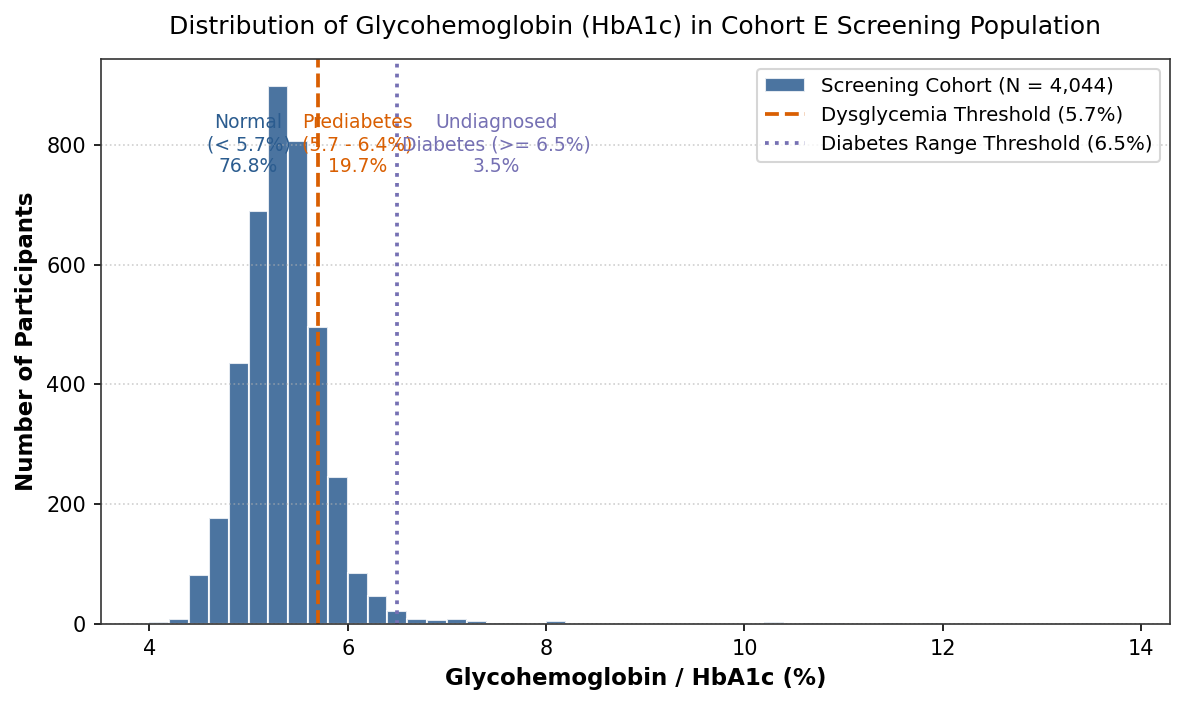

In [10]:
# Summary statistics of candidate predictors in Expanded Complete Cohort
pred_summary = ds_exp[EXPANDED_PREDICTORS].describe().T[["count", "mean", "std", "min", "50%", "max"]]
pred_summary.columns = ["N", "Mean", "SD", "Min", "Median", "Max"]
display(pred_summary)

# Plotting HbA1c Distribution in Screening Population
fig, ax = plt.subplots(figsize=(8, 4.8), dpi=150)

hba1c_vals = ds_exp["LBXGH"]
ax.hist(hba1c_vals, bins=np.arange(4.0, 14.0, 0.2), color="#2b5c8f", edgecolor="white", alpha=0.85, label="Screening Cohort (N = 4,044)")

# Diagnostic and screening threshold lines
ax.axvline(5.7, color="#d95f02", linestyle="--", linewidth=1.8, label="Dysglycemia Threshold (5.7%)")
ax.axvline(6.5, color="#7570b3", linestyle=":", linewidth=1.8, label="Diabetes Range Threshold (6.5%)")

ax.set_xlabel("Glycohemoglobin / HbA1c (%)", fontsize=11, fontweight="bold")
ax.set_ylabel("Number of Participants", fontsize=11, fontweight="bold")
ax.set_title("Distribution of Glycohemoglobin (HbA1c) in Cohort E Screening Population", fontsize=12, pad=12)
ax.legend(frameon=True, facecolor="white", edgecolor="#cccccc", fontsize=9.5)
ax.grid(axis="y", linestyle=":", alpha=0.6)

# Annotate clinical interpretation
ax.text(5.0, ax.get_ylim()[1]*0.80, "Normal\n(< 5.7%)\n76.8%", horizontalalignment="center", fontsize=9, color="#2b5c8f")
ax.text(6.1, ax.get_ylim()[1]*0.80, "Prediabetes\n(5.7 - 6.4%)\n19.7%", horizontalalignment="center", fontsize=9, color="#d95f02")
ax.text(7.5, ax.get_ylim()[1]*0.80, "Undiagnosed\nDiabetes (>= 6.5%)\n3.5%", horizontalalignment="center", fontsize=9, color="#7570b3")

plt.show()


## 12. Key Methodological Takeaways for the Modeling Phase

1. **Target Authenticity:** The target `hba1c_dysglycemia` is defined by CDC phlebotomy-validated laboratory measurements, providing a reliable ground truth for Stage-1 non-laboratory screening.
2. **Deterministic Reproducibility:** In-memory reconstruction replicates the locked Phase 3 canonical datasets (`analytic_core_complete.parquet`, $N = 4,194$; `analytic_expanded_complete.parquet`, $N = 4,044$) with zero discrepancy.
3. **Leakage Elimination:** Prohibited outcome, cohort-selection, and survey metadata variables are strictly quarantined from Stage-1 predictor matrices.
4. **Transparent Trade-off:** The Core (5 inputs) and Expanded (7 inputs) feature sets are frozen and ready for deterministic train/test splitting and benchmark modeling in **Notebook 02**.
